In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import json
from ipysigma import Sigma

import sys
sys.path.append('../')
from source import Align

In [ ]:
BlastPairWiseAlignmentPivoted = pd.read_csv("../data/processed/BlastPairWiseAlignmentPivoted.cov80.maxseq1.csv", sep="\t")
mask = np.triu(np.ones_like(BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"), dtype=bool)) 
sns.heatmap(
    BlastPairWiseAlignmentPivoted.set_index("Unnamed: 0"),
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidth=.5,
    mask=mask,
)
plt.title("Databases Redudancy (>95% identity)")

In [ ]:
BlastPairWiseAlignmentPivoted

In [ ]:
ClustersCdHit = pd.read_csv(
    "../data/processed/cdhitclusters.defaultsettings.csv",
    sep = "\t",
)
sns.lineplot(
    ClustersCdHit.set_index("Unnamed: 0"),
    marker = "o"
)
plt.xlabel("Identity Threshold (%)")
plt.ylabel("Database Size")

In [ ]:
ClustersCdHit

In [ ]:
PairWiseAlignment = pd.read_csv(
    "../data/filtered/AllDatabases.Paiwise.cov80.maxseq1.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
PairWiseAlignment["qcov"] = np.round((PairWiseAlignment["qend"] - PairWiseAlignment["qstart"] + 1) / (PairWiseAlignment["qlen"]) * 100, 2)
PairWiseAlignment["scov"] = np.round((PairWiseAlignment["send"] - PairWiseAlignment["sstart"] + 1) / (PairWiseAlignment["slen"]) * 100, 2)
PairWiseAlignment["qseqtag"] = PairWiseAlignment["qseqid"].str.split("|").str[1]
PairWiseAlignment["sseqtag"] = PairWiseAlignment["sseqid"].str.split("|").str[1]
PairWiseAlignment["qseqid"] = PairWiseAlignment["qseqid"].str.split("|").str[0]
PairWiseAlignment["sseqid"] = PairWiseAlignment["sseqid"].str.split("|").str[0]

In [ ]:
PairWiseAlignment

In [ ]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="qcov", 
    y="pident",
    size = "bitscore",
    )

In [ ]:
sns.scatterplot(
    data=PairWiseAlignment.loc[PairWiseAlignment["bitscore"] > 50], 
    x="pident", 
    y="ppos",
    size = "bitscore",
    )

In [ ]:
PairWiseAlignment

In [ ]:
with open("../data/processed/MetaDict.cov80.maxseq1.json", "r") as json_file  :
    MetaDict = json.load(json_file)

In [ ]:
SequenceSimilarityGraph = nx.from_pandas_edgelist(
    PairWiseAlignment.loc[PairWiseAlignment["pident"] > 80], 
    source="qseqid", 
    target="sseqid", 
    edge_attr=["pident", "bitscore", "evalue","bitscore", "ppos"]
)
nx.set_node_attributes(SequenceSimilarityGraph, MetaDict)
ConnectedComponents = list(nx.connected_components(SequenceSimilarityGraph))
len(ConnectedComponents)

In [ ]:
ProblematicComponents = set()
ComponentIndex = dict()
DivergenteAnnotatedClasses = []
for i, component in enumerate(ConnectedComponents):
    ComponentGraph = SequenceSimilarityGraph.subgraph(component)
    Classes = [ComponentGraph.nodes[n].get("Drug Class") for n in component]
    if len(set(Classes)) > 1:
        ComponentIndex[i] = {"status": "problematic", "component": component, "classes": set(Classes), "len": len(component)}
        ProblematicComponents = ProblematicComponents.union(component)
        DivergenteAnnotatedClasses.append(set(Classes))
    else:
        ComponentIndex[i] = {"status": "ok", "component": component, "classes": set(Classes), "len": len(component)}

In [ ]:
ClassCount = []
for item in pd.Series(DivergenteAnnotatedClasses):
    for c in item:
        ClassCount.append(c)
pd.Series(ClassCount).value_counts().head(30).to_frame().plot(kind = "barh", figsize=(1,5.5))

In [ ]:
TargetClass = "multidrug"
pd.Series([c for c in DivergenteAnnotatedClasses if TargetClass in c]).value_counts().head(10).to_frame().plot(kind = "barh", figsize=(1,5))

In [51]:
TargetClass = "multidrug"
ProblematicCompWithTargetClass = set()
for key, value in ComponentIndex.items():
    if value["status"] == "problematic":
        if TargetClass in value["classes"]:
            ProblematicCompWithTargetClass = ProblematicCompWithTargetClass.union(value["component"])
ProblematicComponentsByClass = SequenceSimilarityGraph.subgraph(ProblematicCompWithTargetClass)
meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.2,                 # Reduza para não amontoar no centro
    "repulsion": 2,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicComponentsByClass, 
    node_size  = ProblematicComponentsByClass.degree(), 
    node_color =  [ProblematicComponentsByClass.nodes[n].get("Drug Class") for n in ProblematicComponentsByClass.nodes()],
    # node_metrics={"community": "louvain"},

    default_edge_type = "curve",
    layout_settings=meu_layout,
    start_layout=30,
    )

Sigma(nx.Graph with 4,664 nodes and 4,182 edges)

In [65]:
SelectedCompIndex = None
NodeBait = "NCRD_2373"
for key,value in ComponentIndex.items():
    if NodeBait in value["component"]:
        print(key)
        SelectedCompIndex = key

SelectedCluster = SelectedCompIndex
StringFasta = []
for protein in ComponentIndex[SelectedCluster]["component"]:
    print(f">{protein}|{ProblematicComponentsByClass.nodes[protein]['Drug Class']}\n{ProblematicComponentsByClass.nodes[protein]['Sequence']}")
    StringFasta.append(f">{protein}|{ProblematicComponentsByClass.nodes[protein]['Drug Class']}\n{ProblematicComponentsByClass.nodes[protein]['Sequence']}")

795
>NCRD_33135|na
MAIVKPQPDPTLEWFLSHCHIHKYAAKSSLIHQGEKSETLYYIVKGSVAVLIKDEDGKEMILSYLNQGDFIGELGLFEEGQVRSAWVKAKTSCEVAEISYKKFKQLIQVNPEILMRLSAQMANRLQSTSKKVGNLAFLDVTGRIAQTLLNLAKQPDSMTHPDGMQIKITRQEIGQIVGCSRETVGRILKMLEDQGLISAHGKTIVVFGTR
>NCRD_30301|na
MVLGKPQTDPTLEWFLSHCHIHKYPSKSTLIHQGEKAETLYYIVKGSVAVLIKDEEGKEMILSYLNQGDFIGELGLFEEGQERSAWVRAKTACEVAEISYKKFRQLIQVNPDILMRLSSQMARRLQVTSEKVGNLAFLDVTGRIAQTLLNLAKQPDAMTHPDGMQIKITRPGNWSDRRLLS
>NCRD_2373|na
MRGSHHHHHHGSMVLGKPQTDPTLEWFLSHCHIHKYPSKSTLIHQGEKAETLYYIVKGSVAVLIKDEEGKEMILSYLNQGDFIGELGLFEEGQERSAWVRAKTACEVAEISYKKFRQLIQVNPDILMRLSAQMARRLQVTSEKVGNLAFLDVTGRIAQTLLNLAKQPDAMTHPDGMQIKITRQEIGQIVGCSRETVGRILKMLEDQNLISAHGKTIVVYGTR
>NCRD_30035|na
MILGKPQIDYTLEWFLLHCHIHKYSAKCILINQGEKAETLYYIIKGSVVVLIKDEDGKEMILSYLNQGDFIGELCLFEESKERTAWVRSKTSCEIAEISYKKFRQLIQINSDILVRLSSQIARRLQITSEKVGNLAFLDVTGRIAQTLLSLAKQPDAMTHPDGMQIKITRQEIGQIVGCSRETVGRILKMLENQKLISAHGKTIVVYGTR
>NCRD_11677|multidrug
NQGDFFGEPGLFEECQERCAWVRAKTACEVAEISYKKFRQLIQVNPDILMRFSAQMARRLQVTSEKVGNLSFLDVT
>NCRD_21659

In [ ]:
ProblematicComponentsByClass

In [52]:
ProblematicCompoLenDist = [value["len"] for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Problematic Component Sizes')

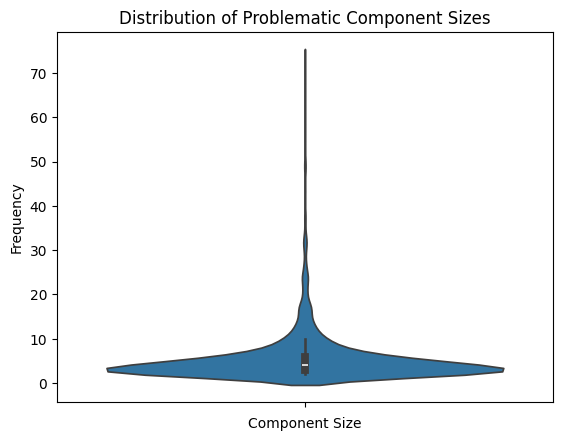

In [53]:
sns.violinplot(ProblematicCompoLenDist)
plt.xlabel("Component Size")
plt.ylabel("Frequency")
plt.title("Distribution of Problematic Component Sizes")

In [54]:
ProblematicCompoClassDist = [len(value["classes"]) for key, value in ComponentIndex.items() if value["status"] == "problematic"]

Text(0.5, 1.0, 'Distribution of Number of Classes in Problematic Component Sizes')

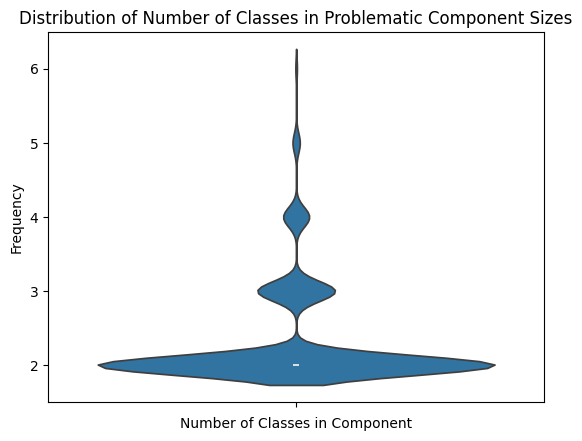

In [55]:
sns.violinplot(ProblematicCompoClassDist)
plt.xlabel("Number of Classes in Component")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Classes in Problematic Component Sizes")

In [56]:
def ConcateComponentsBy(CompDict, OriginalGraph, Minsize = None, MinClassNumber = None):
    if Minsize is None and MinClassNumber is None:
        raise ValueError("At least one of Minsize or MinClassNumber must be provided. Both cannot be None.")
    elif Minsize is not None and MinClassNumber is not None:
        raise ValueError("Only one of Minsize or MinClassNumber can be provided. Both cannot be set at the same time.")
    
    ConcateComponents = set()
    for key, value in CompDict.items():
        if Minsize is not None and value["len"] >= Minsize and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])

        elif MinClassNumber is not None and len(value["classes"]) >= MinClassNumber and value["status"] == "problematic":
            ConcateComponents = ConcateComponents.union(value["component"])            
    return OriginalGraph.subgraph(ConcateComponents),ConcateComponents

In [57]:
# ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, MinClassNumber = 3)
# meu_layout = {
#     "scalingRatio": 50.0,           # Aumente para afastar os grupos
#     "gravity": 0.2,                 # Reduza para não amontoar no centro
#     "repulsion": 2,               # Aumente para afastar os nós
#     # "outboundAttractionDistribution": True, # Empurra hubs para fora
#     # "barnesHutOptimize": True,      # Essencial para seus 70k nós
#     # "linLogMode": True              # Melhora a definição de clusters biológicos 
# }
# Sigma(
#     ProblematicSubGraph, 
#     node_size  = ProblematicSubGraph.degree(), 
#     node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
#     # node_metrics={"community": "louvain"},

#     default_edge_type = "curve",
#     layout_settings=meu_layout,
#     start_layout=30,
#     )

In [58]:
# ProblematicSubGraph, ConcateComponents = ConcateComponentsBy(ComponentIndex, SequenceSimilarityGraph, Minsize = 10)
# meu_layout = {
#     "scalingRatio": 50.0,           # Aumente para afastar os grupos
#     "gravity": 0.2,                 # Reduza para não amontoar no centro
#     "repulsion": 2,               # Aumente para afastar os nós
#     # "outboundAttractionDistribution": True, # Empurra hubs para fora
#     # "barnesHutOptimize": True,      # Essencial para seus 70k nós
#     # "linLogMode": True              # Melhora a definição de clusters biológicos 
# }
# Sigma(
#     ProblematicSubGraph, 
#     node_size  = ProblematicSubGraph.degree(), 
#     node_color =  [ProblematicSubGraph.nodes[n].get("Drug Class") for n in ProblematicSubGraph.nodes()],
#     # node_metrics={"community": "louvain"},

#     default_edge_type = "curve",
#     layout_settings=meu_layout,
#     start_layout=30,
#     )

In [59]:
ComponentIndex

{0: {'status': 'ok',
  'component': {'CARD_0',
   'HMD_11487',
   'HMD_12623',
   'HMD_4222',
   'HMD_8208',
   'HMD_9529',
   'MEGARES_1086',
   'MEGARES_1087',
   'NCRD_16945',
   'NDARO_1066'},
  'classes': {'beta-lactam'},
  'len': 10},
 1: {'status': 'ok',
  'component': {'CARD_1',
   'HMD_829',
   'MEGARES_4627',
   'NDARO_8793',
   'NDARO_8827',
   'RESFINDER_1099'},
  'classes': {'beta-lactam'},
  'len': 6},
 2: {'status': 'problematic',
  'component': {'CARD_2',
   'NCRD_0',
   'NCRD_18559',
   'NCRD_21335',
   'NCRD_8349',
   'NDARO_1354'},
  'classes': {'diaminopyrimidine', 'trimethoprim'},
  'len': 6},
 3: {'status': 'ok',
  'component': {'CARD_3',
   'HMD_1374',
   'MEGARES_1622',
   'NDARO_4551',
   'RESFINDER_599'},
  'classes': {'beta-lactam'},
  'len': 5},
 4: {'status': 'ok',
  'component': {'CARD_4',
   'HMD_247',
   'MEGARES_2711',
   'NDARO_5885',
   'RESFINDER_1518'},
  'classes': {'beta-lactam'},
  'len': 5},
 5: {'status': 'ok',
  'component': {'CARD_5',
   'HMD

885


>NCRD_8930|glycopeptide
MKIAISGTGYVGLSNGLLIAQQHEVIALDIIPERVQMLNARKSPIVDKEIEQYLKLDTIRFKATVDKELAYKDADFVIIATPTDYDPKTNYFNTTSVESVIDDVVRVNPSAVMVIKSTVPVGFTDAMKKKFGTENIIFSPEFLREGKALYDNLHPSRIVIGERSARAEKFASLLQQGAIKQNIPVLFTDSTEAEAIKLFANTYLAMRVAYFNELDSYAESLGLNTRQIIEGVCLDPRIGNHYNNPSFGYGGYCLPKDTKQLLANYQSVPNNIISAIVDANRTRKDFIADSILARQPKVVGIYRLIMKSGSDNFRASSIQGIMKRIKAKGIPVIIYEPVMQEDSFFNSRVVRDLDAFKEEADVIISNRMAEELIDVADKVYTRDLFGND
>NCRD_12942|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQSDEIHFNATLGKVRTS
>NCRD_21911|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQSDKIHFNATLDKNEAYRDADYVIIATPTDYDPKTNYFNTSSVESVIKDVVEINPYAVMVIKSTVPVGFTAAMHKKYRTENIIFSPEFLREGKALYDNLHPSRIVIGERSERAERFAALLQEGAIKQDIPTLFTDSTEAEAIKLFANTYLALRVAYFNELDSYAESQGLNSKQIIEGVCLDPRIGNHYNNPSFGYGGYCLPKDTKQLLANYESVPNNIIAAIVDANRTRKDFIADSILARKPKVVGVYRLIMKSGSDNFRASSIQGIMKRIKAKGIPVIIYEPVMQEDEFFNSRVVRDLDTFKQEADVIISNRMAEELADVADKVYTRDLFGSD
>NCRD_18205|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIL

In [62]:
AlignedComponent = Align.ProteinAligner(StringFasta)

In [63]:
for i, seq in enumerate(AlignedComponent):
    print(f">{seq.id}")
    print(seq.seq)

>NCRD_8930|glycopeptide
MKIAISGTGYVGLSNGLLIAQQHEVIALDIIPERVQMLNARKSPIVDKEIEQYLKLDTIRFKATVDKELAYKDADFVIIATPTDYDPKTNYFNTTSVESVIDDVVRVNPSAVMVIKSTVPVGFTDAMKKKFGTENIIFSPEFLREGKALYDNLHPSRIVIGERSARAEKFASLLQQGAIKQNIPVLFTDSTEAEAIKLFANTYLAMRVAYFNELDSYAESLGLNTRQIIEGVCLDPRIGNHYNNPSFGYGGYCLPKDTKQLLANYQSVPNNIISAIVDANRTRKDFIADSILARQPKVVGIYRLIMKSGSDNFRASSI---QGIMKRIKAKGIPVIIYEPVMQEDSFFNSRVVRDLDAFKEEADVIISNRMAEELIDVADKVYT------------------------RDLFGND-------------------
>NCRD_12942|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQSDEIHFNATLGK-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------VRTS----------------------------------------------------------------------------------------------------------------------
>NCRD_21911|glycopeptide
MKITISGTGYVGLSNGLLIAQNHEVVALDILPSRVAMLNDRISPIVDKEIQQFLQS